# Obesity

In [1]:
import pandas as pd
import numpy as np

ds_url = "https://raw.githubusercontent.com/aap-unlp/datasets/main/obesity_uci/obesity_uci.csv"

try:
    df = pd.read_csv(ds_url)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Ejercicio 5

C:\Users\gonza\AppData\Local\Temp\ipykernel_13804\3966685675.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=fam_his_weight, x=weight_data, palette='Set2', width=0.5)


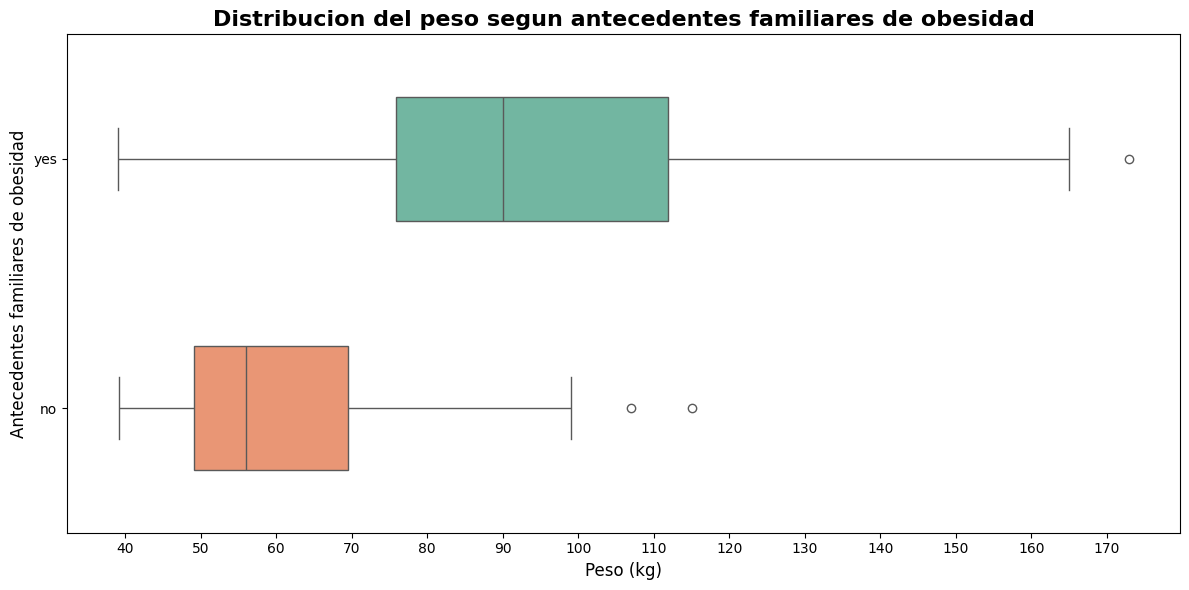

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Calcular medidas
weight_data = df['Weight'].dropna()
q1 = weight_data.quantile(0.25)
q2 = weight_data.quantile(0.50)
q3 = weight_data.quantile(0.75)
iqr = q3 - q1
fam_his_weight = df['family_history_with_overweight'].dropna()

# Configurar el estilo
plt.figure(figsize=(12, 6))
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

# Crear diagrama de caja
sns.boxplot(y=fam_his_weight, x=weight_data, palette='Set2', width=0.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(10))
plt.title('Distribucion del peso segun antecedentes familiares de obesidad',
          fontsize=16, fontweight='bold')
plt.xlabel('Peso (kg)', fontsize=12)
plt.ylabel('Antecedentes familiares de obesidad', fontsize=12)

plt.tight_layout()
plt.show()

In [15]:

# Calcular los estadísticos por categoría
summary = {}
for cat, subset in df.groupby("family_history_with_overweight")["Weight"]:
    q1 = subset.quantile(0.25)
    q2 = subset.quantile(0.50)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    lower_whisker = subset[subset >= q1 - 1.5*iqr].min()
    upper_whisker = subset[subset <= q3 + 1.5*iqr].max()

    summary[cat] = [
        subset.min(),
        subset.max(),
        q1,
        q2,
        q3,
        iqr,
        lower_whisker,
        upper_whisker
    ]

# Crear DataFrame con los resultados
tabla = pd.DataFrame(
    summary,
    index=[
        "Mínimo",
        "Máximo",
        "Q1",
        "Q2 (Mediana)",
        "Q3",
        "RIC",
        "Bigote Inferior",
        "Bigote Superior"
    ]
)

print(tabla)

                         no         yes
Mínimo            39.101805   39.000000
Máximo           115.000000  173.000000
Q1                49.039794   75.851219
Q2 (Mediana)      56.000000   89.986675
Q3                69.500000  111.839011
RIC               20.460206   35.987792
Bigote Inferior   39.101805   39.000000
Bigote Superior   99.000000  165.057269


# Titanic

In [18]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/aap-unlp/datasets/main/titanic/titanic.csv"

try:
    df = pd.read_csv(url)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"📊 Dimensiones: {df.shape}")
    display(f"📋 Columnas: {list(df.columns)}")
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!
📊 Dimensiones: (891, 12)


"📋 Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']"

# Ejercicio 7

In [20]:
# Imprimir primeras 5 filas y resumen estadistico
print(f"\n🔍 Primeras 5 filas:")
display(df.head(5))
print(f"\n Resumen estadistico:")
display(df.describe())


🔍 Primeras 5 filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



 Resumen estadistico:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200
